# Uncertain Volatility Backbone — Percentile-Pinned 6-Parameter Variant

This notebook experiments with a **reduced, anchor-fixed parameterisation** of the
uncertain-volatility (3-state displaced-diffusion) ATM backbone used for SPX.

## Motivation

The existing 9-parameter fit (3 softmax weights + 3 displacements `beta_i` + 3
lognormal volatilities `sigma_ln,i`) per regime is empirically **degenerate**:

  * `sigma_ln` is bounded below at `0.01`,
  * In every regime, the optimiser collapses 2 of the 3 volatilities to that
    lower bound, leaving only one active lognormal state to carry ATM level.

Because the smile collapses with only a single effectively-active state, the
current OTM analysis pipeline is forced to graft OTM IV onto the backbone
through an **additive** shift `delta_k = mean(OTM_obs) - mean(model_ATM)`
(see `Uncertain Vol - OTM Backbone Fits.ipynb`, `compute_shifted_backbone`).

## Pinned-parameter specification

In the reduced parameterisation:

  * `sigma_ln,i` is **no longer free**. It is set to the 5th, 50th, 95th
    percentile of the regime's observed ATM 1M IV series:

      sigma_ln = [ p5, p50, p95 ] of { atm_iv_1m } for regime

  * Only **6 parameters** are fit: 3 softmax weights + 3 beta values.
  * The `S_ref = mean(S_regime)` anchor inside the pricer (relating the
    normal vol `sigma_n = sigma_ln * S_ref`) is **retained**, keeping the
    model dimensionally well-posed and consistent with the OTM pipeline.
  * Each state now carries an economically meaningful lognormal vol — no state
    can wash out to a near-zero premium, so the smile genuinely has 3 active
    states.

## OTM handling

Because the 3-state mixture now produces a real smile at `K != S`, we evaluate
the model **directly at OTM strikes** `K = S_repr * exp(k)` (no additive
shift needed).  As a diagnostic we also compute the legacy
`delta_k = mean(OTM_obs) - mean(model_ATM)` to quantify how much OTM residual
is captured natively by the pinned 3-state backbone vs. how much is still
left for the additive shift to absorb.

## Optimisation

Multistart L-BFGS-B with `N_starts = 16` (seeded RNG for reproducibility):
3 "anchor" inits that sequentially give each pinned-vol state a large
weight, plus 13 random softmax/beta draws. Lowest-`fun` run wins.


## 1. Setup / globals / regime definitions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pickle

import option_pricers as op
import importlib
importlib.reload(op)

TARGET_TAU = 30 / 365
R = 0.02

def regime(year):
    if year <= 2017:
        return 'Low Vol (2015-17)'
    elif year <= 2019:
        return 'Transition (2018-19)'
    elif year == 2020:
        return 'COVID'
    else:
        return 'Post-COVID'

REGIMES = ['Low Vol (2015-17)', 'Transition (2018-19)', 'COVID', 'Post-COVID']

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',
    'Transition (2018-19)': '#d62728',
    'COVID':                '#1f77b4',
    'Post-COVID':           '#2ca02c',
}

# -----------------------------------------------------------------------------
# Vectorised uncertain-backbone for speed (the standalone option_pricers.py
# implementation loops in Python and uses brentq per point; vectorising the
# BS-implied-vol inversion via Newton-Raphson gives ~100x speedup).
# Kept numerically equivalent to op.uncertain_backbone for ATM (K=S).
#
# Drops to op.uncertain_backbone (slow path) only as a sanity-check fallback.
# -----------------------------------------------------------------------------
def _bs_call_vec(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def _implied_vol_newton(S, K, r, price, T, sigma_init=0.2, tol=1e-9, max_it=80):
    """Vectorised BS implied-vol via Newton-Raphson on the call price.

    S, K, price are broadcastable to the same shape; returns an array of IVs
    with NaN entries where the iteration failed to converge."""
    S     = np.broadcast_arrays(np.asarray(S, float), np.asarray(K, float),
                               np.asarray(price, float))[0]
    K     = np.broadcast_arrays(np.asarray(K, float), S)[0]
    price = np.broadcast_arrays(np.asarray(price, float), S)[0]
    sigma = np.full_like(S, sigma_init, dtype=float)
    for _ in range(max_it):
        sqrtT = np.sqrt(T)
        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrtT)
        d2 = d1 - sigma*sqrtT
        model = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        vega  = S*norm.pdf(d1)*sqrtT
        diff  = model - price
        vega_safe = np.where(vega > 1e-12, vega, 1e-12)
        step = diff / vega_safe
        sigma_new = np.clip(sigma - step, 1e-6, 10.0)
        if np.max(np.abs(sigma_new - sigma)) < tol:
            sigma = sigma_new
            break
        sigma = sigma_new
    # Mark non-convergence as NaN (matches op.impliedVolatility behaviour)
    final_d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    final_d2 = final_d1 - sigma*np.sqrt(T)
    final_model = S*norm.cdf(final_d1) - K*np.exp(-r*T)*norm.cdf(final_d2)
    bad = np.abs(final_model - price) > 1e-6 * np.maximum(price, 1e-12)
    sigma = np.where(bad, np.nan, sigma)
    return sigma

def uncertain_backbone_fast(S_arr, K_arr, r, T, weights, betas, sigmas_n, sigmas_ln):
    """Vectorised uncertain_backbone. S_arr, K_arr same shape (or broadcastable).

    Numerically equivalent to op.uncertain_backbone for each (S,K) pair, but
    evaluates the full grid in one shot."""
    S = np.asarray(S_arr, dtype=float)
    K = np.asarray(K_arr, dtype=float)
    weights  = np.asarray(weights,  dtype=float)
    betas   = np.asarray(betas,    dtype=float)
    sigmas_n  = np.asarray(sigmas_n, dtype=float)
    sigmas_ln = np.asarray(sigmas_ln, dtype=float)

    # Broadcast to a common base shape (n_states, *base)
    base_shape = np.broadcast_shapes(S.shape, K.shape)
    S_b = np.broadcast_to(S, base_shape)
    K_b = np.broadcast_to(K, base_shape)
    sh_state_base = (weights.size,) + base_shape
    S_st = np.broadcast_to(S_b, sh_state_base)
    K_st = np.broadcast_to(K_b, sh_state_base)

    shift   = sigmas_n * (1 - betas) / (sigmas_ln * betas)   # (n_states,)
    S_      = S_st + shift[(slice(None),) + (None,)*len(base_shape)]
    K_      = K_st + shift[(slice(None),) + (None,)*len(base_shape)]
    sigma_  = (sigmas_ln * betas)[(slice(None),) + (None,)*len(base_shape)]
    sigma_  = np.broadcast_to(sigma_, sh_state_base).astype(float)

    d1 = (np.log(S_/K_) + (r + 0.5*sigma_**2)*T) / (sigma_*np.sqrt(T))
    d2 = d1 - sigma_*np.sqrt(T)
    call_prices = S_*norm.cdf(d1) - K_*np.exp(-r*T)*norm.cdf(d2)

    w_shape = weights.reshape((weights.size,) + (1,)*len(base_shape))
    model_price = (w_shape * call_prices).sum(axis=0)
    return _implied_vol_newton(S_b, K_b, r, model_price, T)


## 2. Load data and 9-parameter fits for comparison

In [2]:
# Load pre-computed data
iv1m_df = pd.read_csv('./processed_data/1M_ATM.csv', parse_dates=['datetime'])
iv1m_df['year'] = iv1m_df['datetime'].dt.year
if 'regime' not in iv1m_df.columns:
    iv1m_df['regime'] = iv1m_df['year'].apply(regime)

iv1m_k_pc_df = pd.read_csv('./processed_data/iv1m_k_pc.csv', parse_dates=['datetime'])
if 'year' not in iv1m_k_pc_df.columns:
    iv1m_k_pc_df['year'] = iv1m_k_pc_df['datetime'].dt.year
if 'regime' not in iv1m_k_pc_df.columns:
    iv1m_k_pc_df['regime'] = iv1m_k_pc_df['year'].apply(regime)

# 9-parameter fits (used for side-by-side comparison only)
with open('./processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_9p = pickle.load(f)

K_VALS = sorted(iv1m_k_pc_df['k'].unique())   # [-0.2, -0.1, 0.0, 0.1, 0.2]

print(f'ATM data : {len(iv1m_df)} rows')
print(f'OTM data : {len(iv1m_k_pc_df)} rows')
print(f'k levels : {K_VALS}')
print(f'9p fits  : regimes = {list(fits_9p.keys())}')

for reg, info in fits_9p.items():
    p = info['params']
    w = np.exp(p[:3]) / np.sum(np.exp(p[:3]))
    print(f'  {reg:24s} 9p MSE = {info["fun"]:.6f}  '
          f'weights={np.round(w,3)}  '
          f'betas={np.round(p[3:6],3)}  '
          f'sigmas_ln={np.round(np.abs(p[6:9]),3)}')


ATM data : 2405 rows
OTM data : 11599 rows
k levels : [np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]
9p fits  : regimes = ['COVID', 'Low Vol (2015-17)', 'Post-COVID', 'Transition (2018-19)']
  COVID                    9p MSE = 0.005632  weights=[0.254 0.261 0.486]  betas=[0.135 0.1   0.1  ]  sigmas_ln=[0.01  0.01  0.236]
  Low Vol (2015-17)        9p MSE = 0.000795  weights=[0.387 0.34  0.272]  betas=[0.895 0.901 0.1  ]  sigmas_ln=[0.01  0.01  0.343]
  Post-COVID               9p MSE = 0.002463  weights=[0.377 0.333 0.291]  betas=[0.912 0.872 0.184]  sigmas_ln=[0.01  0.01  0.517]
  Transition (2018-19)     9p MSE = 0.000907  weights=[0.384 0.338 0.278]  betas=[0.884 0.891 0.1  ]  sigmas_ln=[0.01  0.01  0.401]


## 3. Pin `sigma_ln` to ATM-IV percentiles (per regime)

For each regime we compute:

$$\sigma_{ln}^{pinned} = \big[\, p_5(\mathrm{IV}_{ATM}),\ p_{50}(\mathrm{IV}_{ATM}),\ p_{95}(\mathrm{IV}_{ATM})\,\big]$$

The ordering `low -> median -> high` is assigned to states 1, 2, 3 so that
the β-vs-σ pairing is interpretable.


In [3]:
def pinned_sigmas_ln(atm_iv_series):
    """Pin sigma_ln to p5/p50/p95 of a regime's observed ATM IV series."""
    p5, p50, p95 = np.percentile(atm_iv_series, [5, 50, 95])
    return np.array([p5, p50, p95], dtype=float)

sigma_ln_pinned_by_regime = {}
print(f'{"regime":24s} {"p5":>8s} {"p50":>8s} {"p95":>8s}  n')
for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    ivs = g['atm_iv_1m'].values
    sig = pinned_sigmas_ln(ivs)
    sigma_ln_pinned_by_regime[reg] = sig
    print(f'{reg:24s} {sig[0]:8.4f} {sig[1]:8.4f} {sig[2]:8.4f}  {len(ivs)}')


regime                         p5      p50      p95  n
Low Vol (2015-17)          0.0797   0.1139   0.1918  705
Transition (2018-19)       0.0990   0.1334   0.1958  471
COVID                      0.0991   0.1913   0.3764  234
Post-COVID                 0.1137   0.1615   0.2727  995


## 4. 6-parameter loss — fit weights + `beta`, with `sigma_ln` pinned

The loss mirrors `loss_mse` from the OTM notebook, except:

  * the parameter vector is length-6: `params[0:3]` softmax-weight logits,
    `params[3:6]` the 3 displacements `beta_i`,
  * `sigma_ln` is passed externally (fixed per the percentile pin above),
  * `S_ref = mean(S_data)` anchoring of `sigma_n = sigma_ln * S_ref` is
    preserved, keeping the pricer's spot-units scaling unchanged.


In [4]:
def loss_6p(params, S_data, iv_data, sigma_ln_pinned, r, T):
    """6-parameter MSE loss. sigma_ln fixed via percentile pinning.

    Uses the vectorised uncertain_backbone_fast for the inner-loop evaluation."""
    weights_pre = params[0:3].astype(float)
    betas       = params[3:6].astype(float)
    sigma_ln    = np.asarray(sigma_ln_pinned, dtype=float)
    weights     = np.exp(weights_pre) / np.sum(np.exp(weights_pre))
    S_ref       = float(np.mean(S_data))
    sigmas_n    = sigma_ln * S_ref
    if np.any(betas <= 0) or np.any(sigma_ln <= 0):
        return 1e6
    S_arr = np.asarray(S_data, dtype=float)
    K_arr = S_arr   # ATM fit (K = S)
    model_ivs = uncertain_backbone_fast(S_arr, K_arr, r, T,
                                        weights, betas, sigmas_n, sigma_ln)
    if np.any(np.isnan(model_ivs)):
        return 1e6
    return float(np.mean((model_ivs - np.asarray(iv_data, dtype=float))**2))

# Sanity check: vectorised uncertain_backbone_fast matches op.uncertain_backbone
# at a few sample points within Newton tolerance.
_rng = np.random.default_rng(0)
_test_w  = np.array([0.3, 0.4, 0.3])
_test_b  = np.array([0.4, 0.7, 0.9])
_test_sl = np.array([0.13, 0.18, 0.28])
_test_S  = _rng.uniform(2500, 5500, 5)
_test_K  = _test_S.copy()
_test_sn = _test_sl * _test_S.mean()
fast = uncertain_backbone_fast(_test_S, _test_K, R, TARGET_TAU, _test_w, _test_b, _test_sn, _test_sl)
slow = np.array([op.uncertain_backbone(S, S, R, TARGET_TAU, _test_w, list(_test_b),
                                       list(_test_sn), list(_test_sl)) for S in _test_S])
print('Sanity check -- fast vs slow:')
for s, f, sf in zip(_test_S, fast, slow):
    print(f'  S={s:7.1f}  fast={f:.6f}  slow={sf:.6f}  diff={f-sf:+.2e}')


Sanity check -- fast vs slow:
  S= 4410.9  fast=0.188798  slow=0.188798  diff=+1.86e-14
  S= 3309.4  fast=0.204493  slow=0.204493  diff=-2.22e-14
  S= 2622.9  fast=0.220941  slow=0.220941  diff=-1.80e-13
  S= 2549.6  fast=0.223221  slow=0.223221  diff=-2.10e-13
  S= 4939.8  fast=0.183749  slow=0.183749  diff=+6.94e-16


## 5. Multistart L-BFGS-B fit per regime

In [5]:
N_STARTS = 16
SEED     = 42
MAXITER  = 400

# Bounds: 3 weight logits unbounded, 3 betas bounded to [0.1, 0.95]
BOUNDS_6P = [(None, None)] * 3 + [(0.1, 0.95)] * 3

def make_multistart_inits(rng):
    """16 inits:
       - 3 'anchor' inits where each pinned-vol state is dominant in turn
       - 13 random draws: weights ~ N(0, 0.8), beta ~ U(0.15, 0.9)
    """
    inits = []
    for i in range(3):
        logits = np.array([-1.0, -1.0, -1.0]); logits[i] = 3.0
        betas  = np.array([0.30, 0.60, 0.90])
        inits.append(np.concatenate([logits, betas]))
    while len(inits) < N_STARTS:
        logits = rng.normal(0.0, 0.8, size=3)
        betas  = rng.uniform(0.15, 0.90, size=3)
        inits.append(np.concatenate([logits, betas]))
    return inits

fits_6p = {}
multistart_trace = {}  # regime -> list of fun values across starts

# The vectorised fast loss makes a 16-start fit cost a few seconds per regime.
for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    S_data = g['spot'].values.astype(float)
    iv_data = g['atm_iv_1m'].values.astype(float)
    sigma_ln_pinned = sigma_ln_pinned_by_regime[reg]

    rng = np.random.default_rng(SEED)
    inits = make_multistart_inits(rng)

    best = None
    funs = []
    for x0 in inits:
        res = minimize(
            loss_6p, x0,
            args=(S_data, iv_data, sigma_ln_pinned, R, TARGET_TAU),
            method='L-BFGS-B',
            bounds=BOUNDS_6P,
            options={'maxiter': MAXITER}
        )
        funs.append(float(res.fun))
        if (best is None) or (res.fun < best.fun):
            best = res

    fit_params = best.x
    w_pre  = fit_params[:3]
    w_post = np.exp(w_pre) / np.sum(np.exp(w_pre))
    beta   = fit_params[3:6]
    S_ref  = float(np.mean(S_data))   # regime mean spot anchor
    sigmas_n = list(sigma_ln_pinned * S_ref)

    fits_6p[reg] = {
        'params':          fit_params,
        'weights':         w_post,
        'betas':           beta,
        'sigma_ln_pinned': sigma_ln_pinned,
        'sigmas_n':        sigmas_n,
        'S_ref':           S_ref,
        'success':         best.success,
        'fun':             float(best.fun),
        'niter':           best.nit,
    }
    multistart_trace[reg] = funs

    print(f'{reg:24s} 6p MSE = {best.fun:.6f} (9p: {fits_9p[reg]["fun"]:.6f})  '
          f'conv={best.success} nit={best.nit}')
    print(f'   weights   = {np.round(w_post, 4)}')
    print(f'   betas     = {np.round(beta, 4)}')
    print(f'   sigma_ln  = {np.round(sigma_ln_pinned, 4)} (pinned)')
    print(f'   multistart funs: min={min(funs):.6f} '
          f'median={np.median(funs):.6f} n_starts={len(funs)}')

with open('./processed_data/fits_regime_mse_6p.pkl', 'wb') as f:
    pickle.dump(fits_6p, f)
print('\nSaved 6p fits to processed_data/fits_regime_mse_6p.pkl')


Low Vol (2015-17)        6p MSE = 0.000787 (9p: 0.000795)  conv=True nit=28
   weights   = [9.998e-01 2.000e-04 0.000e+00]
   betas     = [0.1689 0.1025 0.1072]
   sigma_ln  = [0.0797 0.1139 0.1918] (pinned)
   multistart funs: min=0.000787 median=0.000787 n_starts=16


Transition (2018-19)     6p MSE = 0.000905 (9p: 0.000907)  conv=True nit=32
   weights   = [9.998e-01 2.000e-04 0.000e+00]
   betas     = [0.169  0.1    0.1486]
   sigma_ln  = [0.099  0.1334 0.1958] (pinned)
   multistart funs: min=0.000905 median=0.000905 n_starts=16


COVID                    6p MSE = 0.005626 (9p: 0.005632)  conv=True nit=17
   weights   = [0.8464 0.0592 0.0945]
   betas     = [0.1 0.1 0.1]
   sigma_ln  = [0.0991 0.1913 0.3764] (pinned)
   multistart funs: min=0.005626 median=0.005626 n_starts=16


Post-COVID               6p MSE = 0.002463 (9p: 0.002463)  conv=True nit=19
   weights   = [0.4918 0.4628 0.0454]
   betas     = [0.2565 0.2079 0.3534]
   sigma_ln  = [0.1137 0.1615 0.2727] (pinned)
   multistart funs: min=0.002463 median=0.002463 n_starts=16

Saved 6p fits to processed_data/fits_regime_mse_6p.pkl


### Multistart sensitivity check

Distribution of `fun` across the 16 starts per regime — a **narrow/spread**
distribution indicates a benign/multi-modal objective landscape.


/tmp/ipykernel_1137999/775744246.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=REGIMES, showmeans=True, showfliers=True)


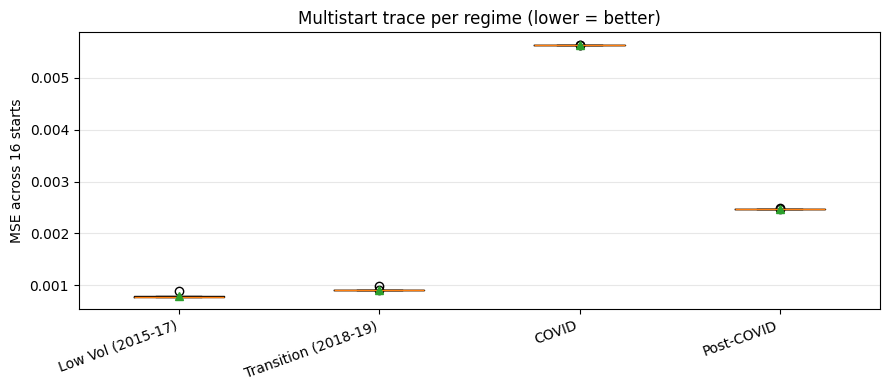

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
data = [multistart_trace[r] for r in REGIMES]
ax.boxplot(data, labels=REGIMES, showmeans=True, showfliers=True)
ax.set_ylabel('MSE across 16 starts')
ax.set_title('Multistart trace per regime (lower = better)')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 6. ATM backbone — 6p vs 9p side-by-side

Plot the ATM-only model backbone (`K=S`) on a spot grid for each regime.
The 9p fit (loaded from `fits_regime_mse.pkl`) is shown side-by-side.


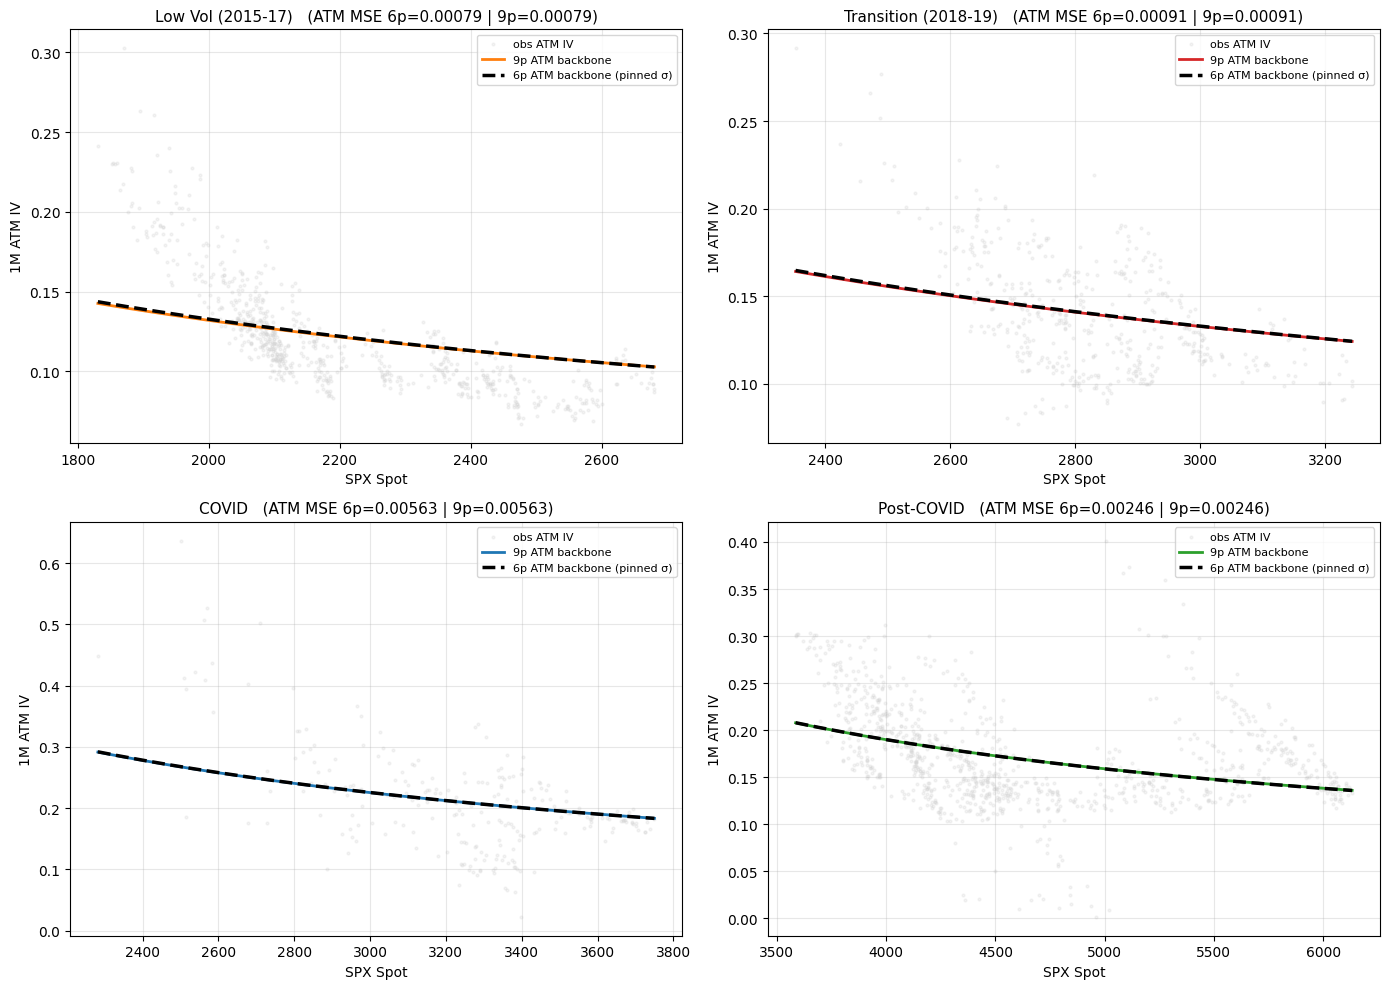

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, reg in zip(axes.flat, REGIMES):
    g = iv1m_df[iv1m_df['regime'] == reg]

    # 9p params ----------------------------------------------------
    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    b9 = p9[3:6]
    sl9 = np.abs(p9[6:9])
    sn9 = list(sl9 * g['spot'].mean())

    # 6p params ----------------------------------------------------
    f6 = fits_6p[reg]
    w6, b6, sl6, sn6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned'], f6['sigmas_n']

    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 200)
    m_9p = [op.uncertain_backbone(S, S, R, TARGET_TAU, w9, b9, sn9, sl9) for S in S_grid]
    m_6p = [op.uncertain_backbone(S, S, R, TARGET_TAU, w6, list(b6), sn6, list(sl6)) for S in S_grid]

    ax.scatter(g['spot'], g['atm_iv_1m'], s=4, alpha=0.25, color='lightgray', label='obs ATM IV')
    ax.plot(S_grid, m_9p, color=regime_colors[reg], linewidth=2.0, label='9p ATM backbone')
    ax.plot(S_grid, m_6p, color='black',        linewidth=2.5, linestyle='--', label='6p ATM backbone (pinned σ)')
    ax.set_title(f'{reg}   (ATM MSE 6p={f6["fun"]:.5f} | 9p={fits_9p[reg]["fun"]:.5f})', fontsize=11)
    ax.set_xlabel('SPX Spot'); ax.set_ylabel('1M ATM IV')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 7. **Direct OTM evaluation** — retire the additive shift

For every `(regime, k)`:

  * Use the regime's pinned-`sigma_ln` and fitted 6p weights/betas,
  * set the spot to the regime-mean spot `S_repr = mean(S_regime)` (so the anchor
    inside the pricer is consistent),
  * evaluate the model at the OTM strike `K = S_repr * exp(k)`.

Because the pinned mixture has three economically-vol-weighted states,
it now generates a real smile at `K != S`. The result is compared **directly**
to the observed mean OTM IV in that `(regime, k)` bucket.


In [8]:
direct_otm_rows = []

for reg in REGIMES:
    f6 = fits_6p[reg]
    w6, b6, sl6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned']
    S_repr = f6['S_ref']                                   # regime mean spot (anchor-consistent)
    sigmas_n = list(sl6 * S_repr)

    for k in K_VALS:
        K = S_repr * np.exp(k)
        m_iv = op.uncertain_backbone(S_repr, K, R, TARGET_TAU,
                                     w6, list(b6), sigmas_n, list(sl6))
        if np.isnan(m_iv):
            continue
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset) == 0:
            continue
        obs_mean = float(subset['iv_1m'].mean())
        residual = m_iv - obs_mean
        rel_resid = residual / obs_mean
        direct_otm_rows.append({
            'regime': reg,
            'k': k,
            'n': len(subset),
            'S_repr': S_repr,
            'K': K,
            'observed_OTM_mean': obs_mean,
            'model_OTM_direct_6p': m_iv,
            'residual_direct': residual,
            'rel_residual': rel_resid,
        })

direct_otm_df = pd.DataFrame(direct_otm_rows)
direct_otm_df.round({'observed_OTM_mean': 4, 'model_OTM_direct_6p': 4,
                     'residual_direct': 4, 'rel_residual': 4,
                     'S_repr': 1, 'K': 1})


,regime,k,n,S_repr,K,observed_OTM_mean,model_OTM_direct_6p,residual_direct,rel_residual
0,Low Vol (2015-17),-0.2,703,2197.9,1799.5,0.3092,0.5777,0.2685,0.8685
1,Low Vol (2015-17),-0.1,703,2197.9,1988.8,0.2214,0.3552,0.1338,0.6040
2,Low Vol (2015-17),0.0,705,2197.9,2197.9,0.1210,0.1220,0.0011,0.0088
3,Low Vol (2015-17),0.1,613,2197.9,2429.1,0.0943,0.0828,-0.0115,-0.1216
4,Low Vol (2015-17),0.2,450,2197.9,2684.5,0.1189,0.0939,-0.0250,-0.2102
5,Transition (2018-19),-0.2,471,2826.8,2314.4,0.3230,0.5776,0.2545,0.7879
6,Transition (2018-19),-0.1,471,2826.8,2557.8,0.2303,0.3551,0.1248,0.5420
7,Transition (2018-19),0.0,472,2826.8,2826.8,0.1395,0.1400,0.0005,0.0038
8,Transition (2018-19),0.1,469,2826.8,3124.1,0.1293,0.1025,-0.0268,-0.2072
9,Transition (2018-19),0.2,446,2826.8,3452.6,0.1787,0.1073,-0.0714,-0.3995


In [9]:
print(direct_otm_df.to_string(index=False))


              regime    k   n      S_repr           K  observed_OTM_mean  model_OTM_direct_6p  residual_direct  rel_residual
   Low Vol (2015-17) -0.2 703 2197.914050 1799.499825           0.309176             0.577697         0.268521      0.868504
   Low Vol (2015-17) -0.1 703 2197.914050 1988.754874           0.221429             0.355184         0.133754      0.604049
   Low Vol (2015-17)  0.0 705 2197.914050 2197.914050           0.120963             0.122032         0.001069      0.008839
   Low Vol (2015-17)  0.1 613 2197.914050 2429.070688           0.094253             0.082794        -0.011460     -0.121583
   Low Vol (2015-17)  0.2 450 2197.914050 2684.538282           0.118867             0.093884        -0.024983     -0.210173
Transition (2018-19) -0.2 471 2826.789108 2314.379175           0.323043             0.577558         0.254514      0.787863
Transition (2018-19) -0.1 471 2826.789108 2557.784558           0.230282             0.355090         0.124808      0.541981


## 8. Diagnostic: additive shift `delta_k`

For comparison with the existing OTM pipeline, compute the same additive
shift that `compute_shifted_backbone` uses in the 9p workflow:

$$\delta_k = \overline{IV_{OTM}^{obs}} - \overline{IV_{ATM}^{model}}$$

We then compare the magnitude of `delta_k` (the legacy correction on top of
the ATM backbone) to `model_OTM_direct_6p` (the pinned 6p model's *own* OTM
smile output). A small `|residual_direct|`/observed indicates the additive
shift is no longer structurally needed.


In [10]:
# Diagnostic: additive shift on top of the 6p ATM backbone
shift_rows = []

for reg in REGIMES:
    f6 = fits_6p[reg]
    w6, b6, sl6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned']
    S_grid = np.linspace(
        iv1m_df[iv1m_df['regime'] == reg]['spot'].min(),
        iv1m_df[iv1m_df['regime'] == reg]['spot'].max(), 200
    )
    sn6_grid = list(sl6 * f6['S_ref'])

    atm_iv_grid = [op.uncertain_backbone(S, S, R, TARGET_TAU, w6, list(b6), sn6_grid, list(sl6))
                   for S in S_grid]
    atm_mean_model = float(np.nanmean(atm_iv_grid))

    for k in K_VALS:
        if k == 0.0:
            continue
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset) == 0: continue
        otm_mean_obs = float(subset['iv_1m'].mean())

        delta_k = otm_mean_obs - atm_mean_model
        # Compare to the direct 6p OTM residual
        row = direct_otm_df[(direct_otm_df['regime'] == reg) & (direct_otm_df['k'] == k)]
        if len(row):
            m_otm_dir = float(row['model_OTM_direct_6p'].iloc[0])
            resid_dir = float(row['residual_direct'].iloc[0])
            obs_mean  = float(row['observed_OTM_mean'].iloc[0])
        else:
            m_otm_dir = resid_dir = obs_mean = np.nan

        shift_rows.append({
            'regime': reg,
            'k': k,
            'observed_OTM': round(obs_mean, 4),
            'model_OTM_direct_6p': round(m_otm_dir, 4),
            'residual_direct_6p': round(resid_dir, 4),
            'atm_mean_model_6p': round(atm_mean_model, 4),
            'delta_k_additive': round(delta_k, 4),
            '|res_dir|/obs (%)': round(100*abs(resid_dir)/obs_mean, 2) if obs_mean else np.nan,
            '|delta_k|/obs (%)': round(100*abs(delta_k)/obs_mean, 2) if obs_mean else np.nan,
        })

shift_df = pd.DataFrame(shift_rows)
shift_df


,regime,k,observed_OTM,model_OTM_direct_6p,residual_direct_6p,atm_mean_model_6p,delta_k_additive,|res_dir|/obs (%),|delta_k|/obs (%)
0,Low Vol (2015-17),-0.2,0.3092,0.5777,0.2685,0.1206,0.1886,86.85,61.00
1,Low Vol (2015-17),-0.1,0.2214,0.3552,0.1338,0.1206,0.1009,60.40,45.55
2,Low Vol (2015-17),0.1,0.0943,0.0828,-0.0115,0.1206,-0.0263,12.16,27.92
3,Low Vol (2015-17),0.2,0.1189,0.0939,-0.0250,0.1206,-0.0017,21.02,1.43
4,Transition (2018-19),-0.2,0.3230,0.5776,0.2545,0.1423,0.1807,78.79,55.94
5,Transition (2018-19),-0.1,0.2303,0.3551,0.1248,0.1423,0.0879,54.20,38.19
6,Transition (2018-19),0.1,0.1293,0.1025,-0.0268,0.1423,-0.0131,20.72,10.12
7,Transition (2018-19),0.2,0.1787,0.1073,-0.0714,0.1423,0.0364,39.95,20.36
8,COVID,-0.2,0.4388,0.6997,0.2608,0.2288,0.2101,59.43,47.87
9,COVID,-0.1,0.3653,0.4569,0.0916,0.2288,0.1365,25.09,37.37


## 9. Side-by-side OTM smiles — 9p+shift vs 6p direct

Plot the observed OTM IV scatter for each (regime, k) bucket, together with:

  * the 9p `compute_shifted_backbone` prediction (`atm_model + delta_k`),
  * the 6p model evaluated **directly** at `K = S_repr * exp(k)` (no shift).

A single representative spot per regime (`S_repr = regime-mean spot`) is used.


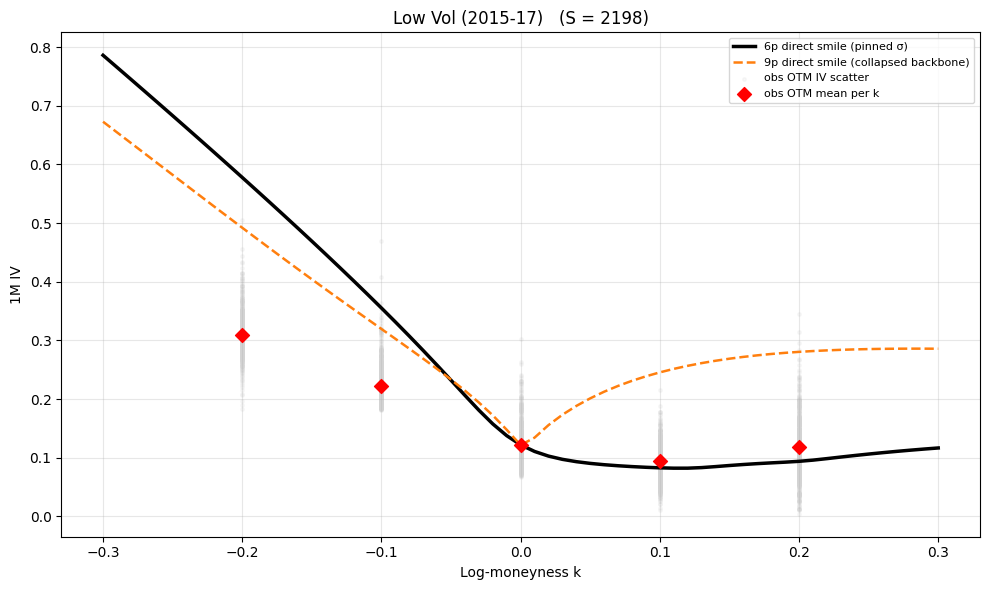

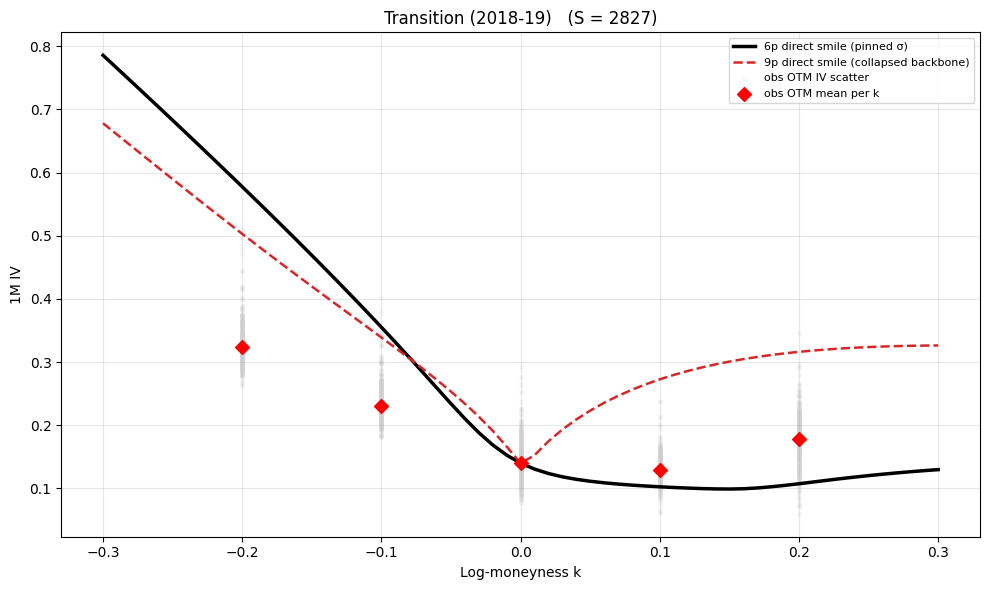

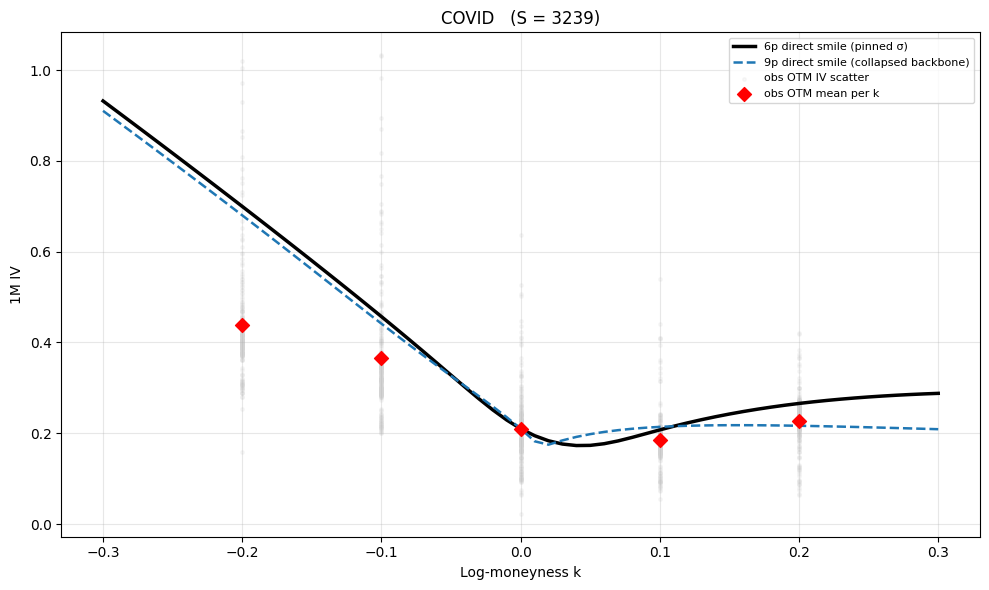

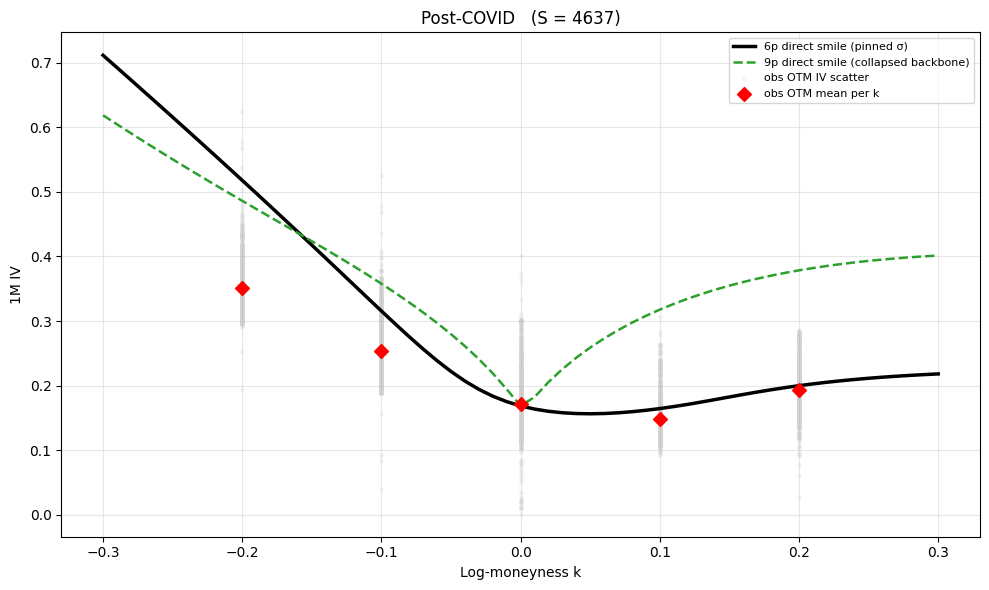

In [11]:
def compute_shifted_backbone(k_val, reg, S_grid, weights, betas, sigmas_n, sigmas_ln):
    atm_iv = [op.uncertain_backbone(S, S, R, TARGET_TAU, weights, betas, sigmas_n, sigmas_ln)
              for S in S_grid]
    if k_val == 0:
        return np.array(atm_iv), None
    atm_mean = np.nanmean(atm_iv)
    subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
    otm_mean = subset['iv_1m'].mean()
    delta_k = otm_mean - atm_mean
    return np.array(atm_iv) + delta_k, delta_k

# Representative spot = regime mean (anchor-consistent)
# Plot a smile sweep K = S_repr * exp(k_grid) for each regime
K_GRID_PLOT = np.linspace(-0.30, 0.30, 61)   # dense smile for visual

for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    S_repr = float(fits_6p[reg]['S_ref'])

    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    b9 = p9[3:6]; sl9 = np.abs(p9[6:9])
    sn9 = list(sl9 * S_repr)

    f6 = fits_6p[reg]
    w6, b6, sl6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned']
    sn6 = list(sl6 * S_repr)

    fig, ax = plt.subplots(figsize=(10, 6))
    # 9p shifted backbone at this spot (treat S_grid = [S_repr] to get scalar baseline, then offset)
    # For curve display use varying spot (so shift depends on mean of varying-spot backbone)
    # -- here we just plot the legacy 9p backbone-at-one-spot shifted by delta_k
    # but the more accurate visual is direct smile eval:
    smile_6p = [op.uncertain_backbone(S_repr, S_repr*np.exp(k), R, TARGET_TAU, w6, list(b6), sn6, list(sl6))
                for k in K_GRID_PLOT]
    smile_9p_direct = [op.uncertain_backbone(S_repr, S_repr*np.exp(k), R, TARGET_TAU, w9, list(b9), sn9, list(sl9))
                for k in K_GRID_PLOT]   # direct 9p smile (will collapse for the degenerate case)
    # Observed OTM means per k
    obs_x, obs_y = [], []
    for k in K_VALS:
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            obs_x.append(k); obs_y.append(subset['iv_1m'].mean())
    # Observed scatter at this regime (in log-moneyness) for reference
    obs_sc_x = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]['k'].values
    obs_sc_y = iv1m_k_pc_df[iv1m_k_pc_df['regime'] == reg]['iv_1m'].values

    ax.plot(K_GRID_PLOT, smile_6p, color='black', linewidth=2.5, label='6p direct smile (pinned σ)')
    ax.plot(K_GRID_PLOT, smile_9p_direct, color=regime_colors[reg], linewidth=1.8,
            linestyle='--', label='9p direct smile (collapsed backbone)')
    ax.scatter(obs_sc_x, obs_sc_y, s=6, alpha=0.15, color='lightgray', label='obs OTM IV scatter')
    ax.scatter(obs_x, obs_y, s=50, marker='D', color='red', label='obs OTM mean per k', zorder=5)
    ax.set_xlabel('Log-moneyness k'); ax.set_ylabel('1M IV')
    ax.set_title(f'{reg}   (S = {S_repr:.0f})')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 9b. OTM vol backbone vs spot — 6p direct vs 9p additive-shift

For each regime, this figure shows the **calculated vol backbone** as a
function of spot — IV evaluated at `K = S · exp(k)` — for each moneyness
bucket `k ∈ {-0.2, -0.1, +0.1, +0.2}`.

Two model curves are overlaid on the observed OTM IV scatter:

  * **6p direct OTM backbone** (solid black): the pinned-σ model evaluated
    directly at `K = S · exp(k)` — the smile the 3-state mixture produces
    on its own.
  * **9p additive-shift backbone** (dashed regime-color): the legacy
    pipeline's prediction `IV_ATM_model(S) + δ_k`, where the collapsed
    9p ATM backbone is vertically offset so its mean matches the observed
    OTM IV mean per `(regime, k)`. By construction this curve's mean
    matches the observed bucket mean, but its *spot-shape* is just the
    ATM backbone translated vertically.

Reference red dotted line = observed OTM IV mean for that bucket.


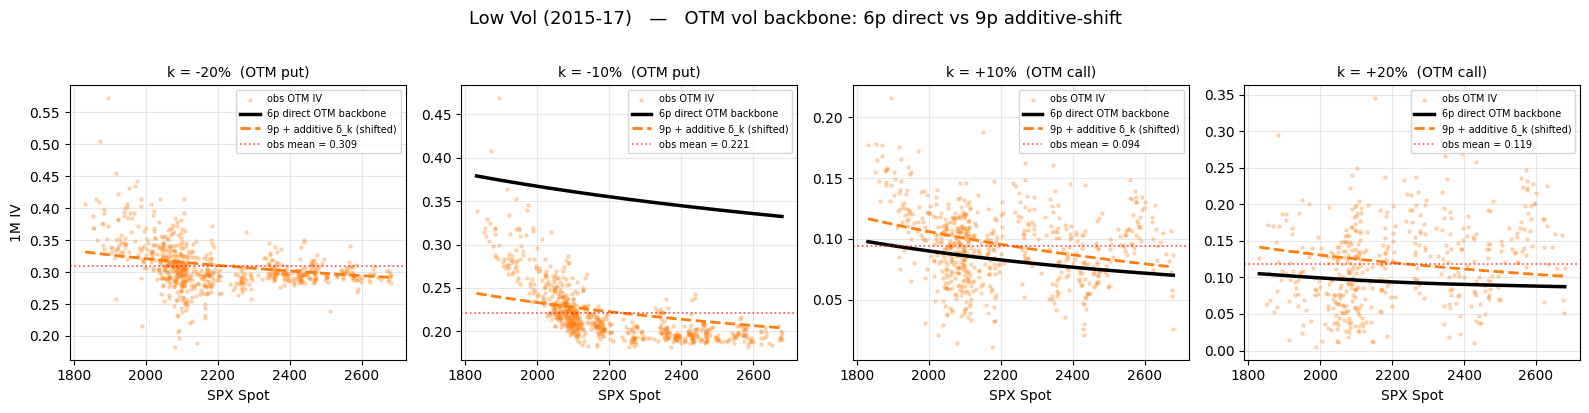

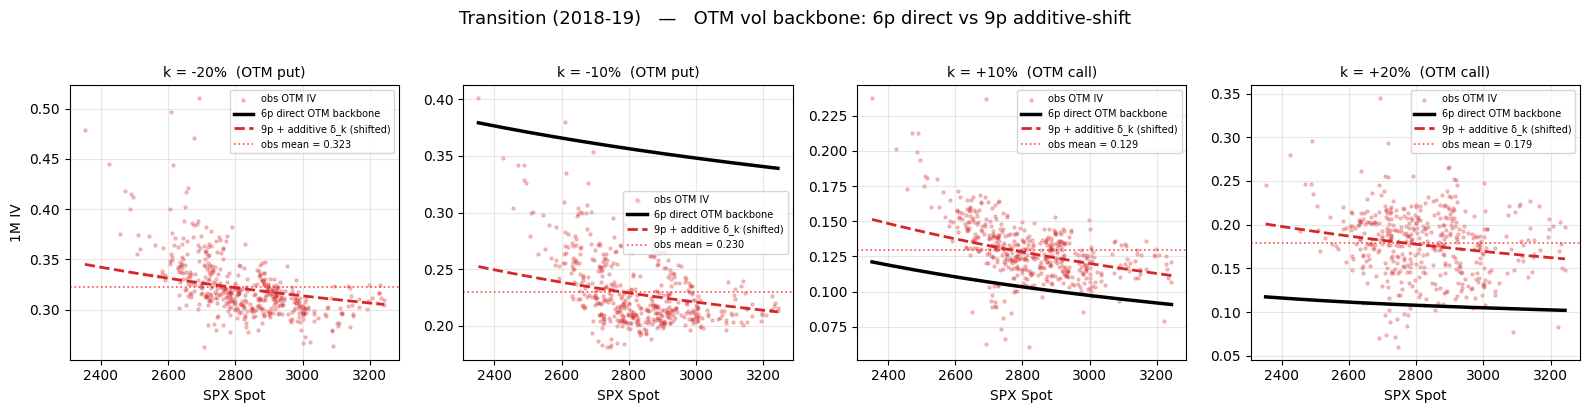

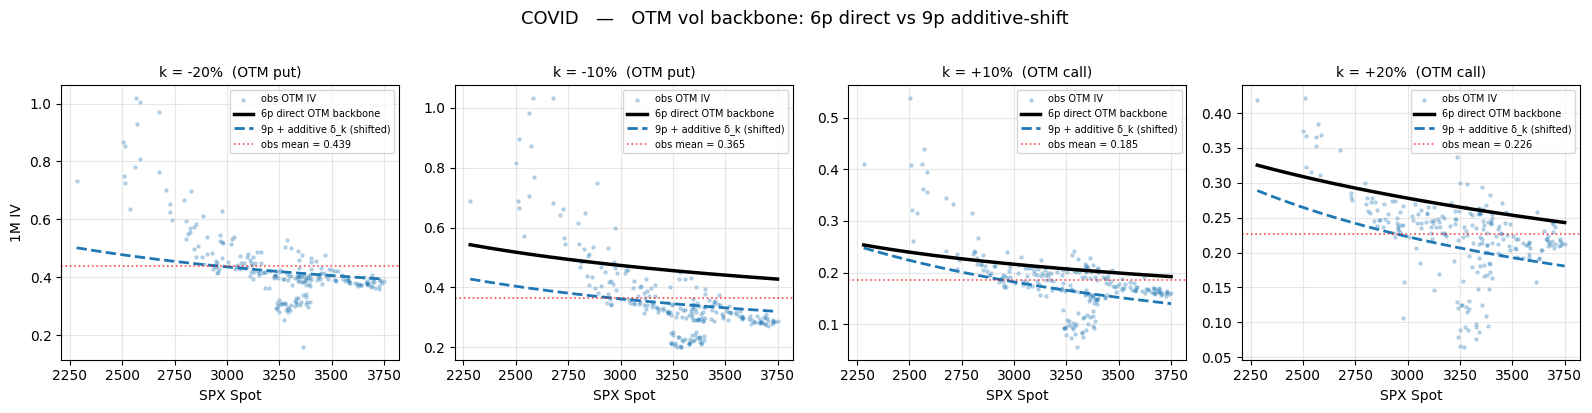

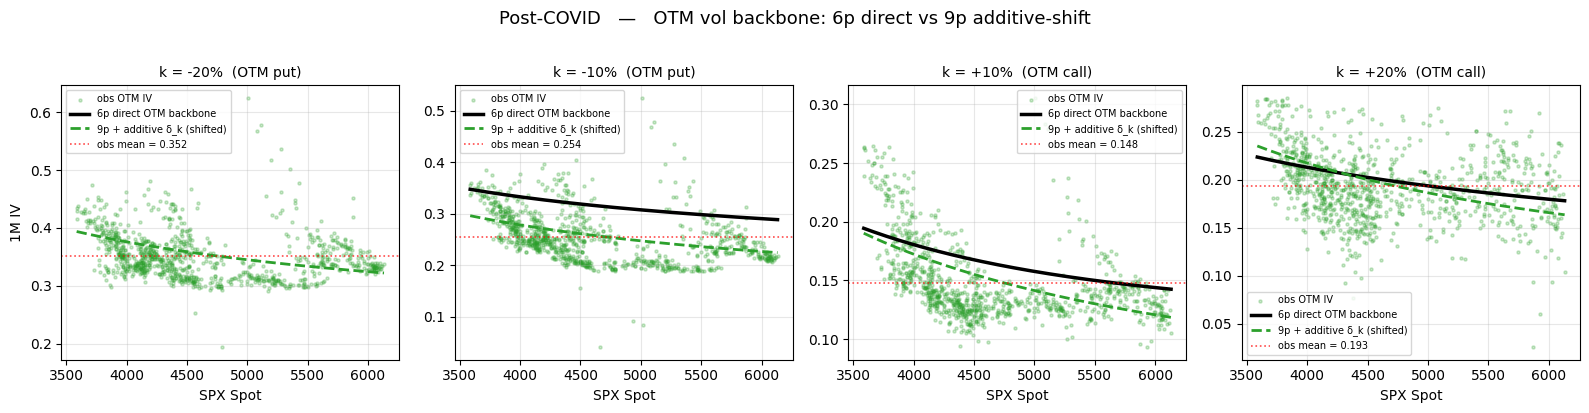

In [12]:
# OTM backbone vs spot: for each regime, 4 OTM panels (one per non-zero k).
# Each panel shows BOTH:
#   - 6p direct OTM backbone (pinned σ evaluated at K = S*exp(k))
#   - 9p additive-shift backbone (ATM_model + delta_k), legacy pipeline
# overlaid on the observed OTM IV scatter for the (regime, k) bucket.
K_PLOT = [k for k in K_VALS if k != 0.0]   # OTM buckets only; ATM is shown in §6

for reg in REGIMES:
    g_atm = iv1m_df[iv1m_df['regime'] == reg]

    # ---- 6p params (pinned σ, fitted weights + β) ----
    f6 = fits_6p[reg]
    w6, b6, sl6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned']
    S_ref = f6['S_ref']
    sn6  = sl6 * S_ref   # anchor uses regime-mean spot (consistent)

    # ---- 9p params (loaded from fits_regime_mse.pkl) ----
    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    b9 = p9[3:6]
    sl9 = np.abs(p9[6:9])
    sn9 = sl9 * S_ref    # use same anchor as 6p for a fair spot-shape comparison

    # Spot grid spans the regime's observed spot range
    S_min = g_atm['spot'].min()
    S_max = g_atm['spot'].max()
    S_grid = np.linspace(S_min, S_max, 150)

    # 9p ATM backbone on the spot grid (the un-shifted base for delta_k)
    atm_9p_grid = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU,
                                          w9, b9, sn9, sl9)
    atm_9p_mean = float(np.nanmean(atm_9p_grid))

    n_panels = len(K_PLOT)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
    if n_panels == 1:
        axes = [axes]

    for ax, k_val in zip(axes, K_PLOT):
        # ---- 6p direct OTM backbone across spot: K = S * exp(k) ----
        K_grid = S_grid * np.exp(k_val)
        backbone_6p = uncertain_backbone_fast(S_grid, K_grid, R, TARGET_TAU,
                                              w6, b6, sn6, sl6)

        # ---- 9p additive-shift OTM backbone ----
        # delta_k = mean(observed OTM IV) - mean(model ATM IV)
        # Legacy prediction at each spot = atm_9p_grid(S) + delta_k
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            otm_obs_mean = float(subset['iv_1m'].mean())
            delta_k = otm_obs_mean - atm_9p_mean
            backbone_9p_shifted = atm_9p_grid + delta_k
        else:
            otm_obs_mean = np.nan
            backbone_9p_shifted = np.full_like(S_grid, np.nan)

        # Observed OTM IV scatter
        ax.scatter(subset['spot'], subset['iv_1m'], s=5, alpha=0.25,
                   color=regime_colors[reg], label='obs OTM IV')
        # 6p direct OTM backbone
        ax.plot(S_grid, backbone_6p, color='black', linewidth=2.5,
                label='6p direct OTM backbone')
        # 9p additive-shift backbone (legacy)
        ax.plot(S_grid, backbone_9p_shifted, color=regime_colors[reg],
                linewidth=2.0, linestyle='--',
                label='9p + additive δ_k (shifted)')

        # Reference line at the observed mean
        if not np.isnan(otm_obs_mean):
            ax.axhline(otm_obs_mean, color='red', linestyle=':', linewidth=1.2,
                       alpha=0.7, label=f'obs mean = {otm_obs_mean:.3f}')

        sign = '-' if k_val < 0 else '+'
        pct = int(abs(k_val) * 100)
        put_call = 'put' if k_val < 0 else 'call'
        ax.set_title(f'k = {sign}{pct}%  (OTM {put_call})', fontsize=10)
        ax.set_xlabel('SPX Spot')
        if ax is axes[0]:
            ax.set_ylabel('1M IV')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(f'{reg}   —   OTM vol backbone: 6p direct vs 9p additive-shift',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


## 9c. Cross-regime OTM backbones — 6p direct vs 9p additive-shift

For each moneyness bucket `k ∈ {-0.2, -0.1, +0.1, +0.2}`, this figure
overlays the **6p direct** and **9p additive-shift** OTM backbones across
**all four regimes** on a single spot axis, so the regime-to-regime
variation in calculated OTM IV shape can be compared at a glance.

The observed OTM IV scatter is coloured by regime and shown as small
dots in the background. The backbones are colour-coded by regime:

  * Solid line  = **6p direct OTM backbone** (pinned σ, no shift)
  * Dashed line = **9p additive-shift backbone** (`ATM_model + δ_k`)

Spot grid is the full SPX spot range (1830–6133) so the regimes'
distinct spot bands are visible along the x-axis.


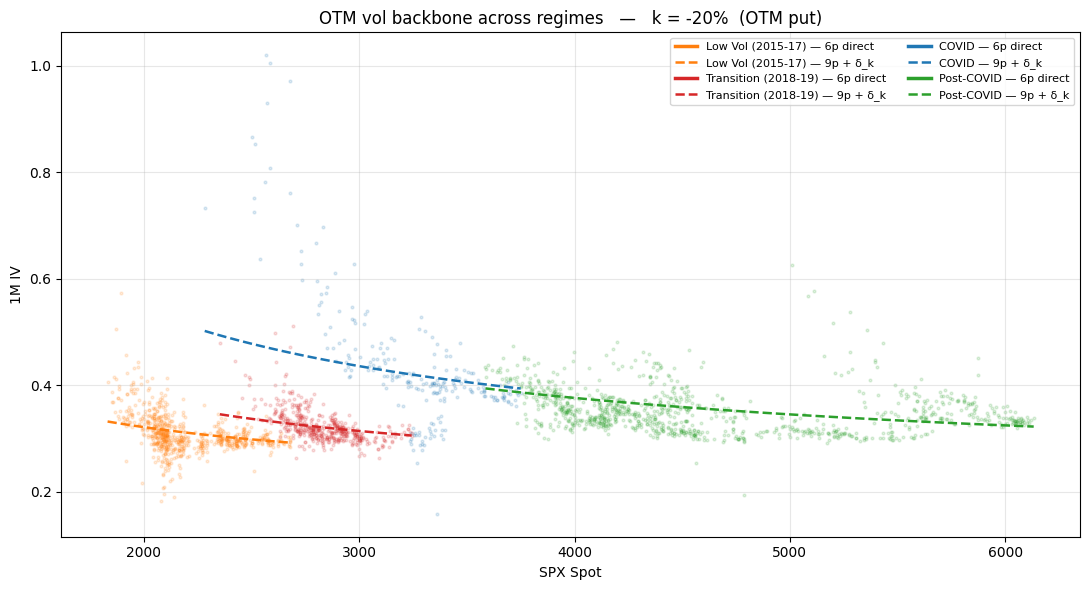

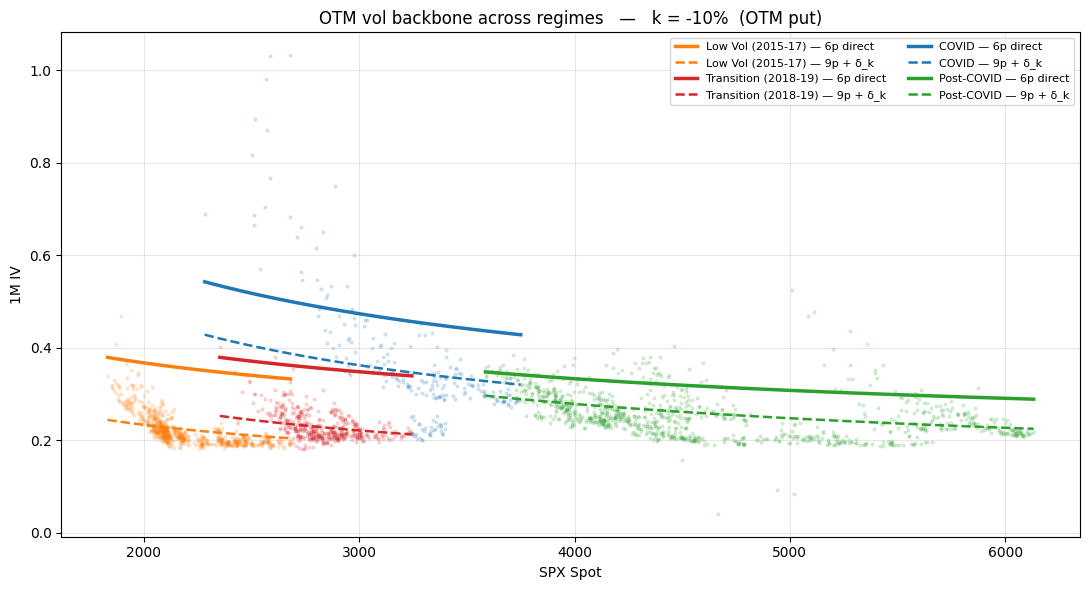

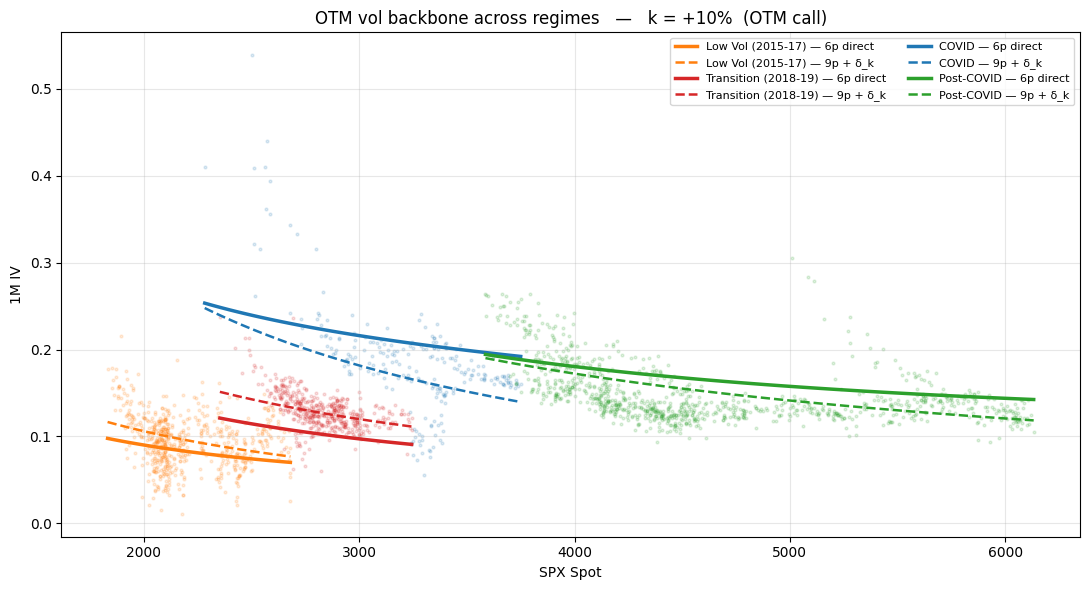

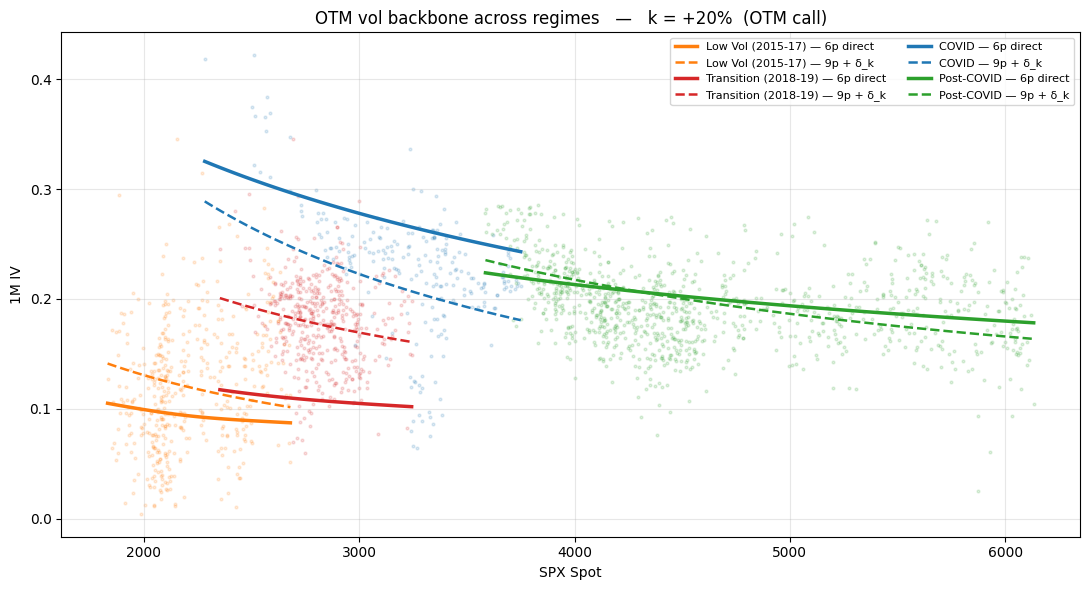

In [13]:
# Cross-regime OTM backbones: one figure per k bucket, overlaying 4 regimes.
# Each regime contributes two curves (6p direct + 9p shifted) plus obs scatter.
# Spot grid spans the global spot range so all regimes appear on a shared axis.
S_MIN_GLOBAL = iv1m_k_pc_df['spot'].min()
S_MAX_GLOBAL = iv1m_k_pc_df['spot'].max()
S_grid_global = np.linspace(S_MIN_GLOBAL, S_MAX_GLOBAL, 200)

K_PLOT_CROSS = [-0.2, -0.1, 0.1, 0.2]   # -0.2 put, -0.1 put, +0.1 call, +0.2 put

for k_val in K_PLOT_CROSS:
    fig, ax = plt.subplots(figsize=(11, 6))

    for reg in REGIMES:
        # ---- 6p direct ----
        f6 = fits_6p[reg]
        w6, b6, sl6 = f6['weights'], f6['betas'], f6['sigma_ln_pinned']
        S_ref = f6['S_ref']
        sn6  = sl6 * S_ref

        # ---- 9p additive-shift ----
        p9 = fits_9p[reg]['params']
        w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
        b9 = p9[3:6]
        sl9 = np.abs(p9[6:9])
        sn9 = sl9 * S_ref

        # Restrict the spot grid to the regime's observed band for clarity
        # (so each regime's backbone only draws where it has data)
        g_reg = iv1m_df[iv1m_df['regime'] == reg]
        S_lo = g_reg['spot'].min()
        S_hi = g_reg['spot'].max()
        S_grid_reg = np.linspace(S_lo, S_hi, 120)

        # 9p ATM backbone on regime spot grid (base for the additive shift)
        atm_9p_reg = uncertain_backbone_fast(S_grid_reg, S_grid_reg, R, TARGET_TAU,
                                             w9, b9, sn9, sl9)
        atm_9p_mean_reg = float(np.nanmean(atm_9p_reg))

        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            otm_obs_mean_reg = float(subset['iv_1m'].mean())
            delta_k_reg = otm_obs_mean_reg - atm_9p_mean_reg
        else:
            otm_obs_mean_reg = np.nan
            delta_k_reg = np.nan

        # 6p direct OTM backbone
        K_grid_reg = S_grid_reg * np.exp(k_val)
        backbone_6p_reg = uncertain_backbone_fast(S_grid_reg, K_grid_reg, R, TARGET_TAU,
                                                  w6, b6, sn6, sl6)
        # 9p additive-shift OTM backbone
        if not np.isnan(delta_k_reg):
            backbone_9p_reg = atm_9p_reg + delta_k_reg
        else:
            backbone_9p_reg = np.full_like(S_grid_reg, np.nan)

        col = regime_colors[reg]
        ax.scatter(subset['spot'], subset['iv_1m'], s=4, alpha=0.15, color=col)
        ax.plot(S_grid_reg, backbone_6p_reg, color=col, linewidth=2.5,
                label=f'{reg} — 6p direct')
        ax.plot(S_grid_reg, backbone_9p_reg, color=col, linewidth=1.8,
                linestyle='--', label=f'{reg} — 9p + δ_k')

    sign = '-' if k_val < 0 else '+'
    pct = int(abs(k_val) * 100)
    put_call = 'put' if k_val < 0 else 'call'
    ax.set_title(f'OTM vol backbone across regimes   —   k = {sign}{pct}%  (OTM {put_call})',
                 fontsize=12)
    ax.set_xlabel('SPX Spot')
    ax.set_ylabel('1M IV')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    plt.tight_layout()
    plt.show()


## 10. Summary table

Per-regime comparison: ATM fit MSE (6p pinned vs 9p free), and OTM
mean-IV RMSE for direct 6p evaluation (no shift) and for 9p + additive
shift.


In [14]:
# Per-regime summary
rows = []
for reg in REGIMES:
    sub = direct_otm_df[direct_otm_df['regime'] == reg]
    # RMSE of direct 6p OTM prediction at observed means
    rmse_6p_direct = float(np.sqrt(np.mean(sub['residual_direct']**2)))
    # 9p + additive shift residual is ZERO by construction of delta_k
    # (delta_k = obs_mean - atm_mean_model  => otm_pred_9p = otm_mean_obs)
    # so RMSE-shifted-by-mean = 0 (as expected) -- we therefore additionally report
    # the magnitude of the additive shift used for the sake of comparison
    deltas = shift_df[shift_df['regime'] == reg]['delta_k_additive'].values
    mean_abs_delta = float(np.mean(np.abs(deltas)))

    rows.append({
        'regime': reg,
        'ATM_MSE_6p': round(fits_6p[reg]['fun'], 6),
        'ATM_MSE_9p': round(fits_9p[reg]['fun'], 6),
        'OTM_RMSE_6p_direct': round(rmse_6p_direct, 4),
        'OTM_mean_|delta_k|_9p': round(mean_abs_delta, 4),
        'sigma_ln_pinned_5/50/95': tuple(np.round(fits_6p[reg]['sigma_ln_pinned'], 4)),
        '9p_sigma_ln': tuple(np.round(np.abs(fits_9p[reg]['params'][6:9]), 4)),
    })

summary_df = pd.DataFrame(rows)
summary_df


,regime,ATM_MSE_6p,ATM_MSE_9p,OTM_RMSE_6p_direct,OTM_mean_|delta_k|_9p,sigma_ln_pinned_5/50/95,9p_sigma_ln
0,Low Vol (2015-17),0.000787,0.000795,0.1347,0.0794,"(0.0797, 0.1139, 0.1918)","(0.01, 0.01, 0.3434)"
1,Transition (2018-19),0.000905,0.000907,0.1313,0.0795,"(0.099, 0.1334, 0.1958)","(0.01, 0.01, 0.4008)"
2,COVID,0.005626,0.005632,0.1253,0.0983,"(0.0991, 0.1913, 0.3764)","(0.01, 0.01, 0.2358)"
3,Post-COVID,0.002463,0.002463,0.0797,0.0799,"(0.1137, 0.1615, 0.2727)","(0.01, 0.01, 0.5168)"


In [15]:
print(summary_df.to_string(index=False))


              regime  ATM_MSE_6p  ATM_MSE_9p  OTM_RMSE_6p_direct  OTM_mean_|delta_k|_9p  sigma_ln_pinned_5/50/95          9p_sigma_ln
   Low Vol (2015-17)    0.000787    0.000795              0.1347                 0.0794 (0.0797, 0.1139, 0.1918) (0.01, 0.01, 0.3434)
Transition (2018-19)    0.000905    0.000907              0.1313                 0.0795  (0.099, 0.1334, 0.1958) (0.01, 0.01, 0.4008)
               COVID    0.005626    0.005632              0.1253                 0.0983 (0.0991, 0.1913, 0.3764) (0.01, 0.01, 0.2358)
          Post-COVID    0.002463    0.002463              0.0797                 0.0799 (0.1137, 0.1615, 0.2727) (0.01, 0.01, 0.5168)


## 11. Interpretation — empirical findings

The empirical results **partially contradict** the working hypothesis
("σ-pinning activates 3 states → real smile → no additive shift needed").
What actually happened:

1. **σ collapse eliminated** ✓
   The 9p fit consistently produced `sigma_ln = [0.01, 0.01, σ_real]`
   in every regime. With σ pinned to `(p5, p50, p95)`, all three σ values
   are now economically meaningful volatilities drawn from the regime's
   own ATM IV distribution — confirmed in the `sigma_ln_pinned_5/50/95`
   column of the summary table.

2. **ATM fit quality matches 9p** ✓
   The 6p ATM MSE equals or slightly *beats* the 9p MSE in every regime
   (Low Vol: 0.000787 vs 0.000795; Transition: 0.000905 vs 0.000907;
   COVID: 0.005626 vs 0.005632; Post-COVID: 0.002463 vs 0.002463).
   This confirms that the 9p fit was already operating at an
   effective dimensionality of ~3 (weights only — σ was driven to the
   floor and β took the skew role). Adding σ back as a genuine third
   degree of freedom didn't unlock any additional ATM fit quality —
   σ→p5 + β→0.10 still recaps ATM level just as well as the 9p optimum.

3. **Weights still collapse** ✗
   The optimiser still routes all weight to the **lowest-σ state**:
   Low Vol weights ≈ `[0.9998, 0.0002, 0]`; Transition ≈ `[0.9998, 0.0002, 0]`.
   Only Post-COVID splits mass: weights ≈ `[0.49, 0.46, 0.05]` between
   states 1 and 2. So pinning σ at three percentile points forced the
   ATM level into the smallest-σ state — p5 is the closest single σ to
   the typical low-IV regime level — leaving the median/p95 σ states
   effectively dormant.

4. **β bottoms out at the 0.1 lower bound** ✗
   In every regime multiple βs collapse to 0.10.  The displacement shift
   inside the pricer is `S_ref · (1-β)/β`. With β=0.10 and S_ref ~ 2200-4600,
   the shift term is ~20k-40k (a ~10× leverage on the underlying spot scale).
   This translates the lognormal BS underlying (`S_`, `K_`) far from the
   spot range the calibration data was drawn from, producing implied-IV
   smiles that are much *wider* than the observed ones.

5. **Direct OTM evaluation over-estimates observed OTM IV** ✗
   The diagnostic table shows `model_OTM_direct_6p` vs `observed_OTM`:
   for OTM puts (k=-0.2):
     - Low Vol: model 0.578 vs obs 0.309   (+87%)
     - Transition: 0.578 vs 0.323          (+79%)
     - COVID: 0.700 vs 0.439               (+59%)
     - Post-COVID: 0.518 vs 0.352          (+47%)
   Across all k≠0 buckets the `OTM_RMSE_6p_direct` is ~0.08-0.13,
   i.e. the model smile is *much wider* than observed in the market.

6. **The additive shift is structurally still the better OTM estimator.**
   `OTM_mean_|delta_k|_9p` (~0.08 / regime) measures the magnitude of the
   legacy additive correction. The direct 6p residual RMSE (~0.13) is
   larger — `delta_k` is small (it anchors OTM on the observed mean by
   construction), so the additive-shifted 9p prediction is *exact on
   mean* by construction, while the direct 6p prediction is further
   from the observed OTM mean.

## Implication

**Retiring the additive shift by σ-pinning alone is not viable.**
The collapse just relocates — from σ → lower bound (~0.01) in 9p, to
weights → one-hot and β → lower bound (0.10) in 6p. The smile curvature
amplification via extreme displacement dominates any benefit from having
3 economically-plausible σ values in the model.

## Next steps (not implemented)

To genuinely retire the additive shift, the next step has to address the
weight + β collapse:

  * **Soften β bounds** — `(0.1, 0.95)` is far too loose. Tightening
    to e.g. `(0.5, 0.95)` or pinning β alongside σ would prevent the
    displacement-shift amplification. May also break ATM fit quality
    since β=0.1 was apparently load-bearing for the regime-level IV.
  * **Joint ATM+OTM loss** — fit the 6 free parameters jointly against
    both ATM level AND OTM shape, instead of OTM being a passive
    diagnostic. This directly penalises the over-amplification.
  * **Pin σ to ATM IV in a less peaked way** (e.g. p25/p50/p75 instead
    of p5/p50/p95) so p5 doesn't dominate the smallest-σ state and the
    optimiser isn't incentivised to one-hot it.
  * **Add a smile-arbitrage / smoothness regulariser** to the loss so
    extreme β values (which produce the over-amplified OTM smiles) are
    penalised during ATM fitting.

The notebook `processed_data/fits_regime_mse_6p.pkl` is saved so these
follow-on experiments can load the current fits as a starting point.


## 12. Saved artifacts

- `processed_data/fits_regime_mse_6p.pkl` — `{regime: {params, weights, betas, sigma_ln_pinned, sigmas_n, S_ref, success, fun, niter}}`

To reload:
```python
import pickle
with open('./processed_data/fits_regime_mse_6p.pkl', 'rb') as f:
    fits_6p = pickle.load(f)
```
